In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_name = "../data/diabetes_data_upload.csv"
df = pd.read_csv(file_name)

In [3]:
print("--- Original Data Shape ---")
print(df.shape)

--- Original Data Shape ---
(520, 17)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [5]:
df

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


In [6]:
mapping = {
    "No":0,
    "Yes":1
}

for col in df.columns.drop(['Age','Gender','class']):
    df[col] = df[col].map(mapping)

In [7]:
df

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,0,1,0,1,0,0,0,1,0,1,0,1,1,1,Positive
1,58,Male,0,0,0,1,0,0,1,0,0,0,1,0,1,0,Positive
2,41,Male,1,0,0,1,1,0,0,1,0,1,0,1,1,0,Positive
3,45,Male,0,0,1,1,1,1,0,1,0,1,0,0,0,0,Positive
4,60,Male,1,1,1,1,1,0,1,1,1,1,1,1,1,1,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,1,1,1,0,1,0,0,1,0,1,1,0,0,0,Positive
516,48,Female,1,1,1,1,1,0,0,1,1,1,1,0,0,0,Positive
517,58,Female,1,1,1,1,1,0,1,0,0,0,1,1,0,1,Positive
518,32,Female,0,0,0,1,0,0,1,1,0,1,0,0,1,0,Negative


In [8]:
gender = {
    "Female":0,
    "Male":1
}

df['Gender'] = df['Gender'].map(gender)

In [9]:
X = df.drop('class',axis=1)
y = df['class']

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X = pd.DataFrame(sc.fit_transform(X),columns=X.columns)

In [17]:
X

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
0,-0.661367,0.765092,-0.992337,1.109847,-0.846269,0.839594,-0.915126,-0.535844,-0.901025,1.027295,-0.565506,1.084312,-0.869918,1.290994,1.380227,2.215647
1,0.821362,0.765092,-0.992337,-0.901025,-0.846269,0.839594,-0.915126,-0.535844,1.109847,-0.973430,-0.565506,-0.922244,1.149534,-0.774597,1.380227,-0.451335
2,-0.578993,0.765092,1.007722,-0.901025,-0.846269,0.839594,1.092746,-0.535844,-0.901025,1.027295,-0.565506,1.084312,-0.869918,1.290994,1.380227,-0.451335
3,-0.249498,0.765092,-0.992337,-0.901025,1.181657,0.839594,1.092746,1.866215,-0.901025,1.027295,-0.565506,1.084312,-0.869918,-0.774597,-0.724518,-0.451335
4,0.986110,0.765092,1.007722,1.109847,1.181657,0.839594,1.092746,-0.535844,1.109847,1.027295,1.768328,1.084312,1.149534,1.290994,1.380227,2.215647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,-0.743741,-1.307032,1.007722,1.109847,1.181657,-1.191052,1.092746,-0.535844,-0.901025,1.027295,-0.565506,1.084312,1.149534,-0.774597,-0.724518,-0.451335
516,-0.002376,-1.307032,1.007722,1.109847,1.181657,0.839594,1.092746,-0.535844,-0.901025,1.027295,1.768328,1.084312,1.149534,-0.774597,-0.724518,-0.451335
517,0.821362,-1.307032,1.007722,1.109847,1.181657,0.839594,1.092746,-0.535844,1.109847,-0.973430,-0.565506,-0.922244,1.149534,1.290994,-0.724518,2.215647
518,-1.320358,-1.307032,-0.992337,-0.901025,-0.846269,0.839594,-0.915126,-0.535844,1.109847,1.027295,-0.565506,1.084312,-0.869918,-0.774597,1.380227,-0.451335


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,shuffle=True,random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression()

In [26]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [27]:
print(y_pred[:5])

['Negative' 'Positive' 'Positive' 'Positive' 'Positive']


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [29]:
score = model.score(X_test, y_test)

# Print the score in the requested format
print("Logistic Regression : {}".format(score))

Logistic Regression : 0.9358974358974359


In [30]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

In [31]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

In [32]:
print("--- CLASSIFICATION REPORT ---")
print(report_df.round(4))

--- CLASSIFICATION REPORT ---
              precision  recall  f1-score   support
Negative         0.9074  0.9074    0.9074   54.0000
Positive         0.9510  0.9510    0.9510  102.0000
accuracy         0.9359  0.9359    0.9359    0.9359
macro avg        0.9292  0.9292    0.9292  156.0000
weighted avg     0.9359  0.9359    0.9359  156.0000


In [33]:
train_score = model.score(X_train, y_train)
train_score

0.9313186813186813

In [34]:
test_score = model.score(X_test, y_test)
test_score

0.9358974358974359

In [35]:
print("\n--- CONFUSION MATRIX ---")
# Creates a readable table structure for the matrix
print(pd.DataFrame(cm, index=model.classes_, columns=[f'Predicted {c}' for c in model.classes_]))


--- CONFUSION MATRIX ---
          Predicted Negative  Predicted Positive
Negative                  49                   5
Positive                   5                  97


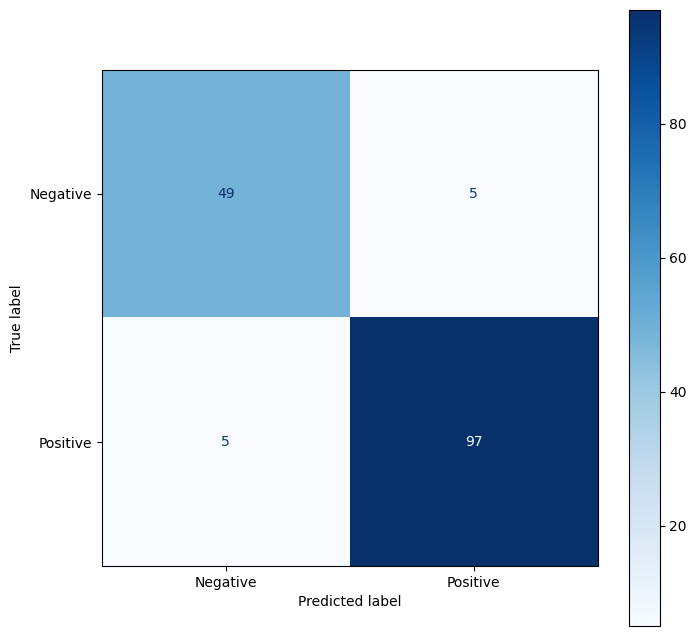

In [37]:
positive_prob = model.predict_proba(X_test)[:, 1]

In [38]:
LOW_RISK_THRESHOLD = 0.30  # Example: Probability below 30%
HIGH_RISK_THRESHOLD = 0.70

In [39]:
def map_risk(prob):
    if prob < LOW_RISK_THRESHOLD:
        return 'Low Risk'
    elif prob < HIGH_RISK_THRESHOLD:
        return 'Moderate Risk'
    else:
        return 'High Risk'

In [40]:
risk_categories = pd.Series(positive_prob).apply(map_risk)

In [41]:
print("\n--- SAMPLE RISK CATEGORIZATION ---")
sample_output = pd.DataFrame({
    'Predicted Probability': positive_prob[:10].round(4),
    'Risk Category': risk_categories[:10]
})
print(sample_output)


--- SAMPLE RISK CATEGORIZATION ---
   Predicted Probability  Risk Category
0                 0.2194       Low Risk
1                 0.9990      High Risk
2                 0.9983      High Risk
3                 0.9996      High Risk
4                 0.6146  Moderate Risk
5                 0.9999      High Risk
6                 0.9057      High Risk
7                 0.1108       Low Risk
8                 0.6995  Moderate Risk
9                 0.0521       Low Risk


In [42]:
import joblib

In [43]:
joblib.dump(model, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [44]:
joblib.dump(sc, 'diabetes_scaler.pkl')

['diabetes_scaler.pkl']